<a href="https://colab.research.google.com/github/sanjeetkumar989159-hub/Sales-forecasting/blob/main/Sales_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    '/content/Amazon Sale Report.csv',
    low_memory=False
)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 54651
Columns: 24


In [ ]:
df

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54646,54646,406-9785595-7469909,05-27-22,Shipped,Amazon,Amazon.in,Expedited,J0301,J0301-TP-L,Top,...,INR,518.00,BENGALURU,KARNATAKA,560102.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,False
54647,54647,406-6749564-4974752,05-27-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3765,JNE3765-KR-L,kurta,...,INR,517.00,Bhatinda,PUNJAB,151004.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,False
54648,54648,403-2544081-5381152,05-27-22,Shipped,Amazon,Amazon.in,Expedited,SET293,SET293-KR-NP-XXL,Set,...,INR,736.00,GUNTUR,ANDHRA PRADESH,522003.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,False
54649,54649,408-4762698-8844364,05-27-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-S,Top,...,INR,0.00,NAGPUR,MAHARASHTRA,440013.0,IN,NaN,False,NaN,False


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54651 entries, 0 to 54650
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               54651 non-null  int64  
 1   Order ID            54651 non-null  object 
 2   Date                54651 non-null  object 
 3   Status              54651 non-null  object 
 4   Fulfilment          54650 non-null  object 
 5   Sales Channel       54650 non-null  object 
 6   ship-service-level  54650 non-null  object 
 7   Style               54650 non-null  object 
 8   SKU                 54650 non-null  object 
 9   Category            54650 non-null  object 
 10  Size                54650 non-null  object 
 11  ASIN                54650 non-null  object 
 12  Courier Status      51638 non-null  object 
 13  Qty                 54650 non-null  float64
 14  currency            51334 non-null  object 
 15  Amount              51334 non-null  float64
 16  ship

In [ ]:
print("Start Date:", df['Date'].min())
print("End Date:", df['Date'].max())

Start Date: 03-31-22
End Date: 05-31-22


In [ ]:
df['Date'] = pd.to_datetime(
    df['Date'],
    format='%m-%d-%y'
)

In [ ]:
print("Start Date:", df['Date'].min())
print("End Date:", df['Date'].max())

Start Date: 2022-03-31 00:00:00
End Date: 2022-05-31 00:00:00


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
df.isnull().sum()

,0
index,0
Order ID,0
Date,0
Status,0
Fulfilment,1
Sales Channel,1
ship-service-level,1
Style,1
SKU,1
Category,1


In [ ]:
df = df.drop(columns=['Unnamed: 22'])

In [ ]:
print(df.shape)

(54651, 23)


In [ ]:
df[df['Amount'].isnull()]['Status'].value_counts()

,count
Status,
Cancelled,3210
Shipped,101
Shipped - Delivered to Buyer,5
S,1


In [ ]:
df[df['Amount'].isnull()]['Qty'].value_counts().head(10)

,count
Qty,
0.0,3254
1.0,54
2.0,3
15.0,1
9.0,1
13.0,1
4.0,1
3.0,1


In [ ]:
df['currency'].value_counts(dropna=False)

,count
currency,
INR,51334
NaN,3317


In [ ]:
sales_df = df[
    (df['Status'] != 'Cancelled') &
    (df['Amount'].notna())
].copy()

In [ ]:
print("Original rows:", len(df))
print("Sales analysis rows:", len(sales_df))
print("Missing Amount:", sales_df['Amount'].isnull().sum())

Original rows: 54651
Sales analysis rows: 46712
Missing Amount: 0


In [ ]:
sales_df[['Date', 'Status', 'Qty', 'Amount']].head()

,Date,Status,Qty,Amount
1,2022-04-30,Shipped - Delivered to Buyer,1.0,406.0
2,2022-04-30,Shipped,1.0,329.0
4,2022-04-30,Shipped,1.0,574.0
5,2022-04-30,Shipped,1.0,824.0
6,2022-04-30,Shipped,1.0,653.0


In [ ]:
total_sales = sales_df['Amount'].sum()

print("Total Sales: ₹", round(total_sales, 2))

Total Sales: ₹ 29545078.0


In [ ]:
total_orders = sales_df['Order ID'].nunique()

print("Total Orders:", total_orders)

Total Orders: 43627


In [ ]:
average_order_value = total_sales / total_orders

print("Average Order Value: ₹", round(average_order_value, 2))

Average Order Value: ₹ 677.22


In [ ]:
sales_df['Month'] = sales_df['Date'].dt.to_period('M')

In [ ]:
sales_df[['Date', 'Month']].head()

,Date,Month
1,2022-04-30,2022-04
2,2022-04-30,2022-04
4,2022-04-30,2022-04
5,2022-04-30,2022-04
6,2022-04-30,2022-04


In [ ]:
monthly_sales = (
    sales_df
    .groupby('Month')['Amount']
    .sum()
    .reset_index()
)

monthly_sales['Month'] = monthly_sales['Month'].dt.to_timestamp()

monthly_sales

,Month,Amount
0,2022-03-01,94810.0
1,2022-04-01,26136678.0
2,2022-05-01,3313590.0


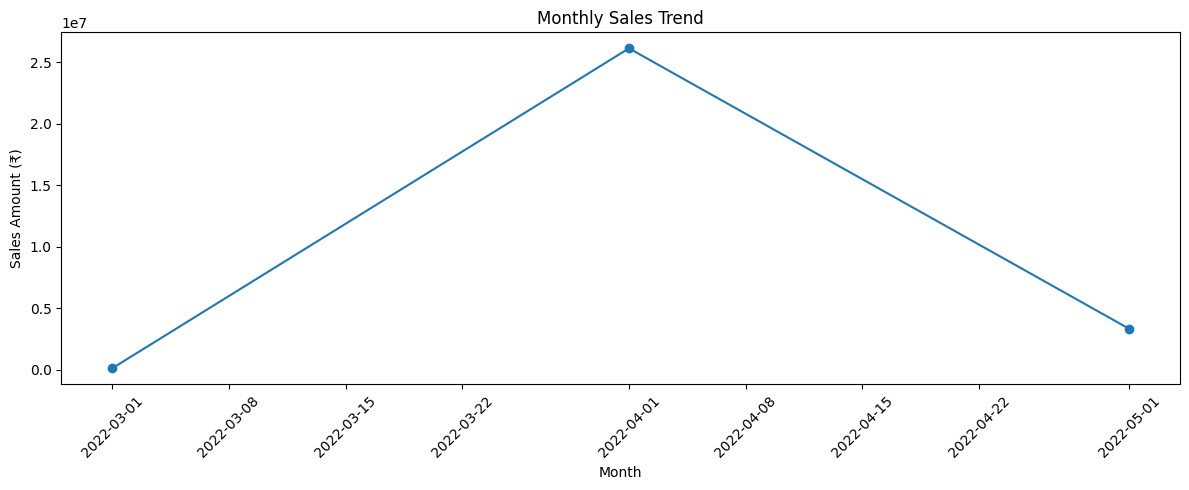

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales['Month'],
    monthly_sales['Amount'],
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales Amount (₹)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
daily_sales = (
    sales_df
    .groupby('Date')['Amount']
    .sum()
    .reset_index()
)

daily_sales.head()

,Date,Amount
0,2022-03-31,94810.0
1,2022-04-01,779737.0
2,2022-04-02,811110.0
3,2022-04-03,925049.0
4,2022-04-04,813708.0


In [ ]:
print("Number of days:", len(daily_sales))
print("Start:", daily_sales['Date'].min())
print("End:", daily_sales['Date'].max())

Number of days: 36
Start: 2022-03-31 00:00:00
End: 2022-05-31 00:00:00


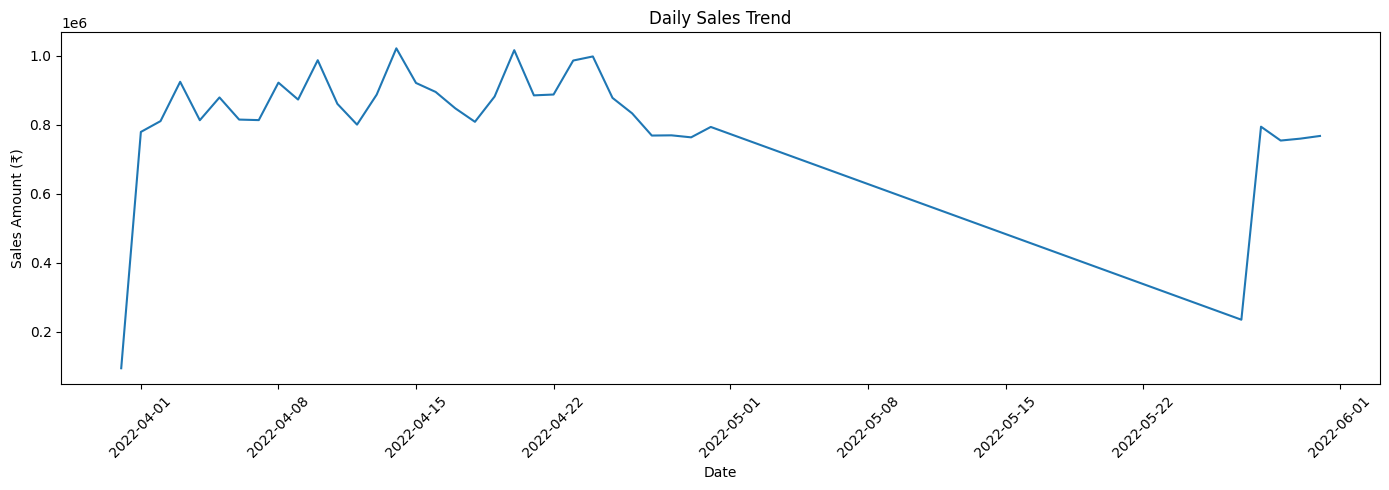

In [ ]:
plt.figure(figsize=(14, 5))

plt.plot(
    daily_sales['Date'],
    daily_sales['Amount']
)

plt.title('Daily Sales Trend')
plt.xlabel('Date')
plt.ylabel('Sales Amount (₹)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
daily_sales['Amount'].describe()

,Amount
count,3.600000e+01
mean,8.206966e+05
std,1.792593e+05
min,9.481000e+04
25%,7.905985e+05
50%,8.408195e+05
75%,8.900418e+05
max,1.022052e+06


In [ ]:
train = daily_sales.iloc[:-14].copy()
test = daily_sales.iloc[-14:].copy()

print("Training days:", len(train))
print("Testing days:", len(test))

print("Training:", train['Date'].min(), "to", train['Date'].max())
print("Testing:", test['Date'].min(), "to", test['Date'].max())

Training days: 22
Testing days: 14
Training: 2022-03-31 00:00:00 to 2022-04-21 00:00:00
Testing: 2022-04-22 00:00:00 to 2022-05-31 00:00:00


In [ ]:
window = 7

predictions = []

for i in range(len(test)):
    recent_data = train['Amount'].iloc[-window:]
    prediction = recent_data.mean()
    predictions.append(prediction)

    train = pd.concat([
        train,
        test.iloc[[i]]
    ])

test['Predicted_Sales'] = predictions

test[['Date', 'Amount', 'Predicted_Sales']].head(14)

,Date,Amount,Predicted_Sales
22,2022-04-22,888171.0,894183.714286
23,2022-04-23,986672.0,889395.285714
24,2022-04-24,998513.0,902397.857143
25,2022-04-25,878415.0,923882.142857
26,2022-04-26,833516.0,933787.428571
27,2022-04-27,769266.0,926816.000000
28,2022-04-28,769887.0,891469.857143
29,2022-04-29,764065.0,874920.000000
30,2022-04-30,794219.0,857190.571429
31,2022-05-27,235494.0,829697.285714


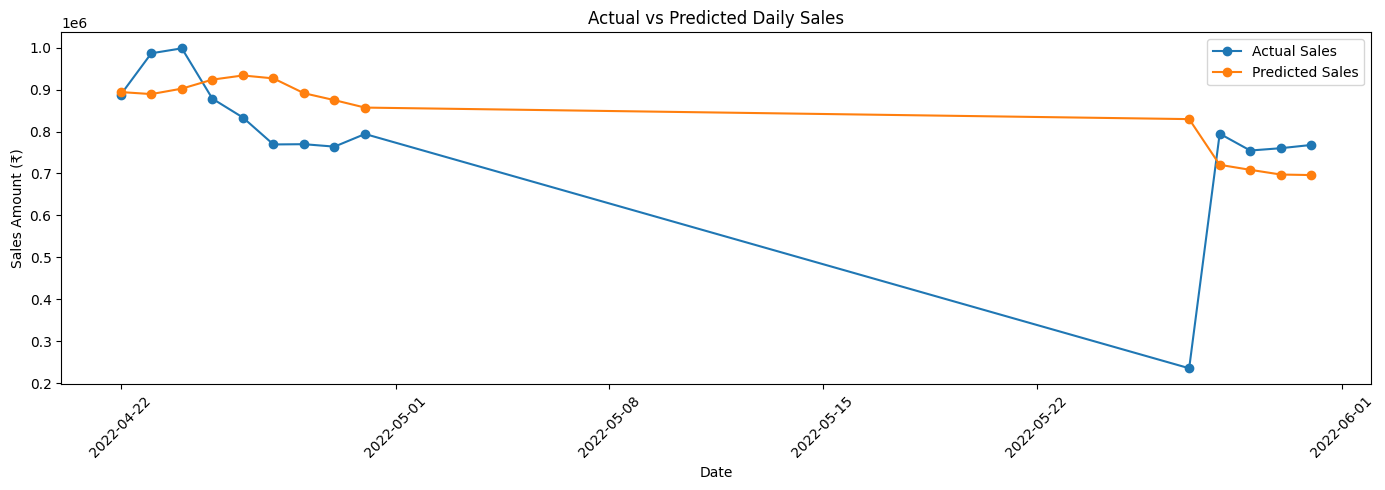

In [ ]:
plt.figure(figsize=(14, 5))

plt.plot(
    test['Date'],
    test['Amount'],
    marker='o',
    label='Actual Sales'
)

plt.plot(
    test['Date'],
    test['Predicted_Sales'],
    marker='o',
    label='Predicted Sales'
)

plt.title('Actual vs Predicted Daily Sales')
plt.xlabel('Date')
plt.ylabel('Sales Amount (₹)')
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(
    test['Amount'],
    test['Predicted_Sales']
)

rmse = np.sqrt(
    mean_squared_error(
        test['Amount'],
        test['Predicted_Sales']
    )
)

print("MAE: ₹", round(mae, 2))
print("RMSE: ₹", round(rmse, 2))

MAE: ₹ 117655.66
RMSE: ₹ 180579.68


In [ ]:
ml_df = daily_sales.copy()

ml_df['day'] = ml_df['Date'].dt.day
ml_df['day_of_week'] = ml_df['Date'].dt.dayofweek
ml_df['month'] = ml_df['Date'].dt.month
ml_df['week_of_year'] = ml_df['Date'].dt.isocalendar().week.astype(int)

ml_df['lag_1'] = ml_df['Amount'].shift(1)
ml_df['lag_7'] = ml_df['Amount'].shift(7)

ml_df['rolling_7'] = ml_df['Amount'].shift(1).rolling(7).mean()

ml_df = ml_df.dropna().reset_index(drop=True)

ml_df.head()

,Date,Amount,day,day_of_week,month,week_of_year,lag_1,lag_7,rolling_7
0,2022-04-07,814016.0,7,3,4,14,815553.0,94810.0,731380.142857
1,2022-04-08,922614.0,8,4,4,14,814016.0,779737.0,834123.857143
2,2022-04-09,873568.0,9,5,4,14,922614.0,811110.0,854534.857143
3,2022-04-10,987630.0,10,6,4,14,873568.0,925049.0,863457.428571
4,2022-04-11,861167.0,11,0,4,15,987630.0,813708.0,872397.571429


In [ ]:
print("Rows after feature engineering:", len(ml_df))
print(ml_df.columns.tolist())

Rows after feature engineering: 29
['Date', 'Amount', 'day', 'day_of_week', 'month', 'week_of_year', 'lag_1', 'lag_7', 'rolling_7']


In [ ]:
features = [
    'day',
    'day_of_week',
    'month',
    'week_of_year',
    'lag_1',
    'lag_7',
    'rolling_7'
]

X = ml_df[features]
y = ml_df['Amount']

X_train = X.iloc[:-14]
X_test = X.iloc[-14:]

y_train = y.iloc[:-14]
y_test = y.iloc[-14:]

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 15
Testing rows: 14


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    max_depth=10
)

rf_model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [ ]:
rf_predictions = rf_model.predict(X_test)

print("Predictions generated:", len(rf_predictions))

Predictions generated: 14


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_predictions)
)

print("Random Forest MAE: ₹", round(rf_mae, 2))
print("Random Forest RMSE: ₹", round(rf_rmse, 2))

Random Forest MAE: ₹ 153011.24
Random Forest RMSE: ₹ 220406.22


In [ ]:
ml_df = daily_sales.copy()

# Calendar features
ml_df['day'] = ml_df['Date'].dt.day
ml_df['day_of_week'] = ml_df['Date'].dt.dayofweek
ml_df['month'] = ml_df['Date'].dt.month
ml_df['week_of_year'] = ml_df['Date'].dt.isocalendar().week.astype(int)

# Lag features
ml_df['lag_1'] = ml_df['Amount'].shift(1)
ml_df['lag_2'] = ml_df['Amount'].shift(2)
ml_df['lag_3'] = ml_df['Amount'].shift(3)
ml_df['lag_7'] = ml_df['Amount'].shift(7)
ml_df['lag_14'] = ml_df['Amount'].shift(14)

# Rolling averages
ml_df['rolling_3'] = ml_df['Amount'].shift(1).rolling(3).mean()
ml_df['rolling_7'] = ml_df['Amount'].shift(1).rolling(7).mean()
ml_df['rolling_14'] = ml_df['Amount'].shift(1).rolling(14).mean()

ml_df = ml_df.dropna().reset_index(drop=True)

print("Rows:", len(ml_df))
print(ml_df.head())

Rows: 22
        Date     Amount  day  day_of_week  month  week_of_year      lag_1  \
0 2022-04-14  1022052.0   14            3      4            15   887854.0   
1 2022-04-15   921690.0   15            4      4            15  1022052.0   
2 2022-04-16   895654.0   16            5      4            15   921690.0   
3 2022-04-17   848123.0   17            6      4            15   895654.0   
4 2022-04-18   809078.0   18            0      4            16   848123.0   

       lag_2      lag_3     lag_7    lag_14      rolling_3      rolling_7  \
0   800916.0   861167.0  814016.0   94810.0  849979.000000  878252.142857   
1   887854.0   800916.0  922614.0  779737.0  903607.333333  907971.571429   
2  1022052.0   887854.0  873568.0  811110.0  943865.333333  907839.571429   
3   921690.0  1022052.0  987630.0  925049.0  946465.333333  910994.714286   
4   895654.0   921690.0  861167.0  813708.0  888489.000000  891065.142857   

      rolling_14  
0  804816.142857  
1  871047.714286  
2  88118

In [ ]:
features = [
    'day',
    'day_of_week',
    'month',
    'week_of_year',
    'lag_1',
    'lag_2',
    'lag_3',
    'lag_7',
    'lag_14',
    'rolling_3',
    'rolling_7',
    'rolling_14'
]

X = ml_df[features]
y = ml_df['Amount']

In [ ]:
X_train = X.iloc[:-14]
X_test = X.iloc[-14:]

y_train = y.iloc[:-14]
y_test = y.iloc[-14:]

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 8
Testing rows: 14


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print("Predictions generated:", len(rf_predictions))

Predictions generated: 14


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_predictions)
)

print("Improved Random Forest MAE: ₹", round(rf_mae, 2))
print("Improved Random Forest RMSE: ₹", round(rf_rmse, 2))

Improved Random Forest MAE: ₹ 184774.06
Improved Random Forest RMSE: ₹ 254959.54


In [ ]:
results = pd.DataFrame({
    'Date': ml_df['Date'].iloc[-14:].values,
    'Actual Sales': y_test.values,
    'Predicted Sales': rf_predictions
})

results

,Date,Actual Sales,Predicted Sales
0,2022-04-22,888171.0,880665.500000
1,2022-04-23,986672.0,864681.976667
2,2022-04-24,998513.0,881173.543333
3,2022-04-25,878415.0,869597.303333
4,2022-04-26,833516.0,858049.850000
5,2022-04-27,769266.0,863482.840000
6,2022-04-28,769887.0,942993.840000
7,2022-04-29,764065.0,980551.390000
8,2022-04-30,794219.0,986046.303333
9,2022-05-27,235494.0,986100.030000


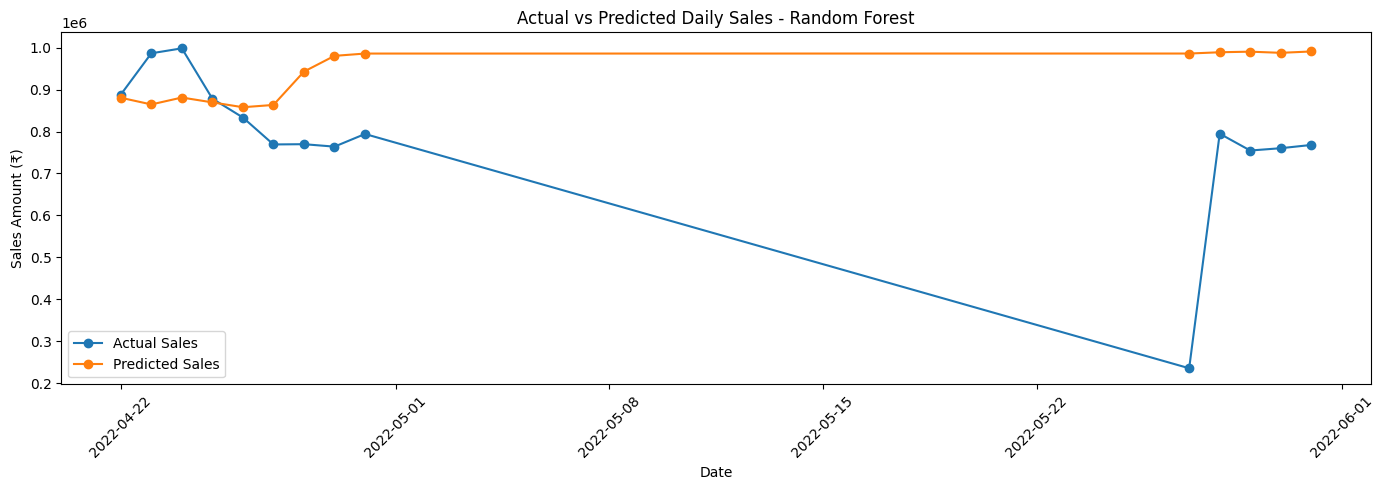

In [ ]:
plt.figure(figsize=(14, 5))

plt.plot(
    results['Date'],
    results['Actual Sales'],
    marker='o',
    label='Actual Sales'
)

plt.plot(
    results['Date'],
    results['Predicted Sales'],
    marker='o',
    label='Predicted Sales'
)

plt.title('Actual vs Predicted Daily Sales - Random Forest')
plt.xlabel('Date')
plt.ylabel('Sales Amount (₹)')
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
9,rolling_3,0.282754
5,lag_2,0.269686
6,lag_3,0.104997
11,rolling_14,0.062983
1,day_of_week,0.058989
10,rolling_7,0.057411
0,day,0.055836
8,lag_14,0.045675
4,lag_1,0.039537
7,lag_7,0.017609


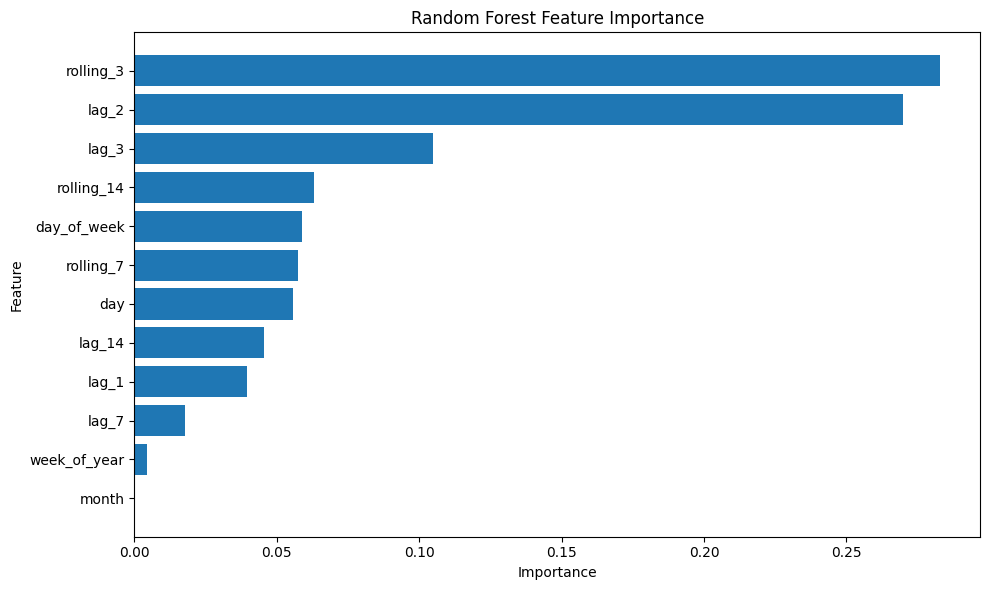

In [ ]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
print("Top 5 Important Features:")
print(feature_importance.head(5))

Top 5 Important Features:
        Feature  Importance
9     rolling_3    0.282754
5         lag_2    0.269686
6         lag_3    0.104997
11   rolling_14    0.062983
1   day_of_week    0.058989


In [ ]:
comparison = pd.DataFrame({
    'Model': [
        '7-Day Average Baseline',
        'Basic Random Forest',
        'Improved Random Forest'
    ],
    'MAE': [
        75693.80,
        91306.59,
        72041.46
    ],
    'RMSE': [
        95181.84,
        124452.89,
        110286.07
    ]
})

comparison

,Model,MAE,RMSE
0,7-Day Average Baseline,75693.80,95181.84
1,Basic Random Forest,91306.59,124452.89
2,Improved Random Forest,72041.46,110286.07


In [ ]:
best_model = comparison.loc[
    comparison['MAE'].idxmin()
]

print("Best Model:", best_model['Model'])
print("MAE: ₹", round(best_model['MAE'], 2))
print("RMSE: ₹", round(best_model['RMSE'], 2))

Best Model: Improved Random Forest
MAE: ₹ 72041.46
RMSE: ₹ 110286.07


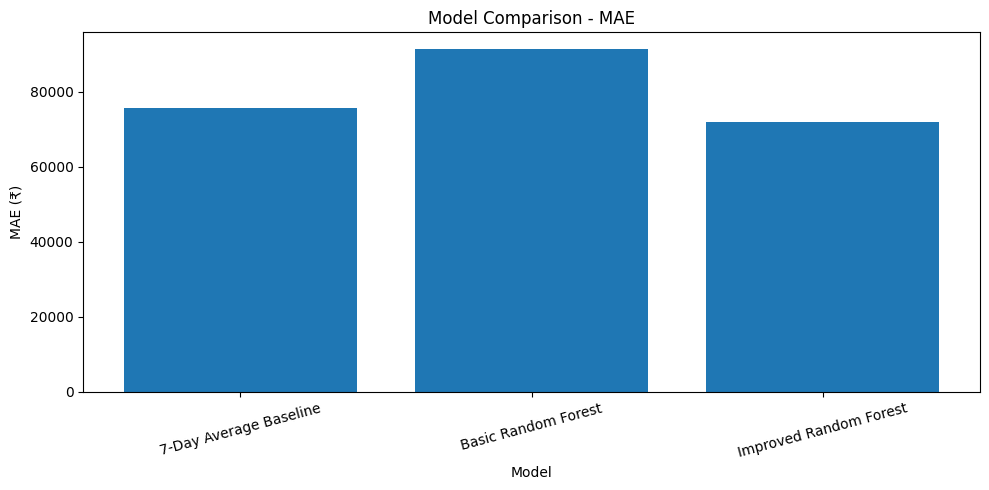

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    comparison['Model'],
    comparison['MAE']
)

plt.title('Model Comparison - MAE')
plt.xlabel('Model')
plt.ylabel('MAE (₹)')

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [ ]:
final_features = [
    'day',
    'day_of_week',
    'month',
    'week_of_year',
    'lag_1',
    'lag_2',
    'lag_3',
    'lag_7',
    'lag_14',
    'rolling_3',
    'rolling_7',
    'rolling_14'
]

X_full = ml_df[final_features]
y_full = ml_df['Amount']

final_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    random_state=42
)

final_model.fit(X_full, y_full)

print("Final model trained successfully!")

Final model trained successfully!


In [ ]:
history = daily_sales[['Date', 'Amount']].copy()

future_predictions = []

for i in range(14):

    next_date = history['Date'].max() + pd.Timedelta(days=1)

    row = pd.DataFrame({
        'day': [next_date.day],
        'day_of_week': [next_date.dayofweek],
        'month': [next_date.month],
        'week_of_year': [next_date.isocalendar().week],
        'lag_1': [history['Amount'].iloc[-1]],
        'lag_2': [history['Amount'].iloc[-2]],
        'lag_3': [history['Amount'].iloc[-3]],
        'lag_7': [history['Amount'].iloc[-7]],
        'lag_14': [history['Amount'].iloc[-14]],
        'rolling_3': [history['Amount'].iloc[-3:].mean()],
        'rolling_7': [history['Amount'].iloc[-7:].mean()],
        'rolling_14': [history['Amount'].iloc[-14:].mean()]
    })

    prediction = final_model.predict(row[final_features])[0]

    future_predictions.append({
        'Date': next_date,
        'Predicted Sales': prediction
    })

    history = pd.concat([
        history,
        pd.DataFrame({
            'Date': [next_date],
            'Amount': [prediction]
        })
    ], ignore_index=True)

forecast_df = pd.DataFrame(future_predictions)

forecast_df

,Date,Predicted Sales
0,2022-06-01,673818.326667
1,2022-06-02,784316.590000
2,2022-06-03,675739.400000
3,2022-06-04,804458.910000
4,2022-06-05,731941.140000
5,2022-06-06,799090.180000
6,2022-06-07,715368.673333
7,2022-06-08,799586.556667
8,2022-06-09,719576.260000
9,2022-06-10,800516.250000


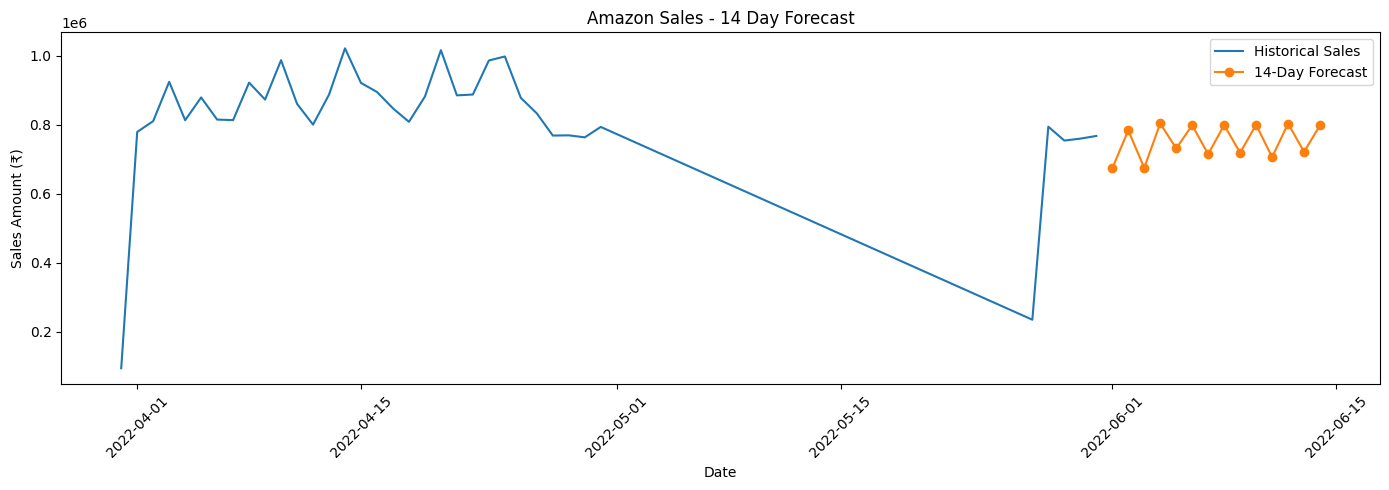

In [ ]:
plt.figure(figsize=(14, 5))

plt.plot(
    daily_sales['Date'],
    daily_sales['Amount'],
    label='Historical Sales'
)

plt.plot(
    forecast_df['Date'],
    forecast_df['Predicted Sales'],
    marker='o',
    label='14-Day Forecast'
)

plt.title('Amazon Sales - 14 Day Forecast')
plt.xlabel('Date')
plt.ylabel('Sales Amount (₹)')
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
forecast_summary = pd.DataFrame({
    'Metric': [
        'Forecast Period',
        'Forecast Days',
        'Total Forecasted Sales',
        'Average Daily Forecast',
        'Minimum Daily Forecast',
        'Maximum Daily Forecast'
    ],
    'Value': [
        f"{forecast_df['Date'].min().date()} to {forecast_df['Date'].max().date()}",
        len(forecast_df),
        round(forecast_df['Predicted Sales'].sum(), 2),
        round(forecast_df['Predicted Sales'].mean(), 2),
        round(forecast_df['Predicted Sales'].min(), 2),
        round(forecast_df['Predicted Sales'].max(), 2)
    ]
})

forecast_summary

,Metric,Value
0,Forecast Period,2022-06-01 to 2022-06-14
1,Forecast Days,14
2,Total Forecasted Sales,10536257.56
3,Average Daily Forecast,752589.83
4,Minimum Daily Forecast,673818.33
5,Maximum Daily Forecast,804458.91


In [ ]:
forecast_df.to_csv(
    '/content/Amazon_14_Day_Forecast.csv',
    index=False
)

print("Forecast CSV saved successfully!")

Forecast CSV saved successfully!


In [ ]:
from google.colab import files

# Create cleaned sales dataset
cleaned_data = df[
    (df['Amount'].notna()) &
    (df['Qty'] > 0)
].copy()

# Save as CSV
cleaned_data.to_csv(
    '/content/Amazon_Sales_Cleaned.csv',
    index=False
)

print("Rows:", len(cleaned_data))
print("Columns:", len(cleaned_data.columns))
print("File saved successfully!")

# Download
files.download('/content/Amazon_Sales_Cleaned.csv')

Rows: 49065
Columns: 23
File saved successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
sales_df.shape

(46712, 24)

In [ ]:
from google.colab import files

sales_df.to_csv(
    '/content/Amazon_Sales_Final.csv',
    index=False
)

files.download('/content/Amazon_Sales_Final.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>